# Digit Classification from Scratch (No Built‑in ML Functions)
This notebook builds a simple neural network **from scratch using only NumPy** to classify handwritten digits.
Dataset: sklearn Digits (only for loading data, not for modeling).

In [2]:
import numpy as np
from sklearn.datasets import load_digits

# Load dataset (8x8 images of digits 0–9)
digits = load_digits()
X = digits.data / 16.0   # Normalize to 0–1
y = digits.target

# One‑hot encode labels manually
num_classes = 10
Y = np.zeros((y.shape[0], num_classes))
for i in range(y.shape[0]):
    Y[i, y[i]] = 1

In [3]:
# Shuffle data

indices = np.arange(X.shape[0])   # [0, 1, 2, ..., N-1]
np.random.shuffle(indices)        # random order

X = X[indices]
Y = Y[indices]


In [4]:
# Split data manually (80/20)
split = int(0.8 * X.shape[0])
X_train, X_test = X[:split], X[split:]
Y_train, Y_test = Y[:split], Y[split:]


In [5]:
input_size = 64
hidden_size1 = 128
hidden_size2 = 64
output_size = 10

np.random.seed(0)

W1 = np.random.randn(input_size, hidden_size1) * 0.1
b1 = np.zeros((1, hidden_size1))

W2 = np.random.randn(hidden_size1, hidden_size2) * 0.1
b2 = np.zeros((1, hidden_size2))

W3 = np.random.randn(hidden_size2, output_size) * 0.1
b3 = np.zeros((1, output_size))


In [6]:
# Activation functions (implemented manually)
def relu(x):
    return np.maximum(0, x)
def softmax(x):
    exp_x = np.exp(x - np.max(x, axis=1, keepdims=True))
    return exp_x / np.sum(exp_x, axis=1, keepdims=True)

In [9]:
# Training loop (Forward + Backprop from scratch)
lr = 0.1
epochs = 1500

for epoch in range(epochs):

    # Forward pass
    Z1 = X_train @ W1 + b1
    A1 = relu(Z1)

    Z2 = A1 @ W2 + b2
    A2 = relu(Z2)

    Z3 = A2 @ W3 + b3
    A3 = softmax(Z3)

    # Loss (cross-entropy)
    loss = -np.mean(np.sum(Y_train * np.log(A3 + 1e-9), axis=1))

    # Backpropagation
    dZ3 = A3 - Y_train
    dW3 = A2.T @ dZ3 / X_train.shape[0]
    db3 = np.sum(dZ3, axis=0, keepdims=True) / X_train.shape[0]

    dA2 = dZ3 @ W3.T
    dZ2 = dA2 * (Z2 > 0)   # ReLU derivative
    dW2 = A1.T @ dZ2 / X_train.shape[0]
    db2 = np.sum(dZ2, axis=0, keepdims=True) / X_train.shape[0]

    dA1 = dZ2 @ W2.T
    dZ1 = dA1 * (Z1 > 0)
    dW1 = X_train.T @ dZ1 / X_train.shape[0]
    db1 = np.sum(dZ1, axis=0, keepdims=True) / X_train.shape[0]

    # Update weights
    W3 -= lr * dW3
    b3 -= lr * db3

    W2 -= lr * dW2
    b2 -= lr * db2

    W1 -= lr * dW1
    b1 -= lr * db1

    if epoch % 20 == 0:
        print(f"Epoch {epoch}, Loss: {loss:.4f}")


Epoch 0, Loss: 0.0560
Epoch 20, Loss: 0.0543
Epoch 40, Loss: 0.0527
Epoch 60, Loss: 0.0512
Epoch 80, Loss: 0.0498
Epoch 100, Loss: 0.0484
Epoch 120, Loss: 0.0471
Epoch 140, Loss: 0.0458
Epoch 160, Loss: 0.0446
Epoch 180, Loss: 0.0435
Epoch 200, Loss: 0.0423
Epoch 220, Loss: 0.0413
Epoch 240, Loss: 0.0402
Epoch 260, Loss: 0.0393
Epoch 280, Loss: 0.0383
Epoch 300, Loss: 0.0374
Epoch 320, Loss: 0.0365
Epoch 340, Loss: 0.0356
Epoch 360, Loss: 0.0348
Epoch 380, Loss: 0.0340
Epoch 400, Loss: 0.0333
Epoch 420, Loss: 0.0325
Epoch 440, Loss: 0.0318
Epoch 460, Loss: 0.0311
Epoch 480, Loss: 0.0304
Epoch 500, Loss: 0.0298
Epoch 520, Loss: 0.0292
Epoch 540, Loss: 0.0285
Epoch 560, Loss: 0.0280
Epoch 580, Loss: 0.0274
Epoch 600, Loss: 0.0268
Epoch 620, Loss: 0.0263
Epoch 640, Loss: 0.0258
Epoch 660, Loss: 0.0253
Epoch 680, Loss: 0.0248
Epoch 700, Loss: 0.0243
Epoch 720, Loss: 0.0238
Epoch 740, Loss: 0.0234
Epoch 760, Loss: 0.0229
Epoch 780, Loss: 0.0225
Epoch 800, Loss: 0.0221
Epoch 820, Loss: 0.021

In [10]:
# Evaluation
Z1 = X_test @ W1 + b1
A1 = relu(Z1)

Z2 = A1 @ W2 + b2
A2 = relu(Z2)

Z3 = A2 @ W3 + b3
A3 = softmax(Z3)

predictions = np.argmax(A3, axis=1)
actual = np.argmax(Y_test, axis=1)

accuracy = np.mean(predictions == actual)
print("Test Accuracy:", accuracy)


Test Accuracy: 0.9666666666666667


In [11]:
import pandas as pd

df = pd.DataFrame({
    "Actual": actual,
    "Predicted": predictions
})

df.head(20)


,Actual,Predicted
0,7,7
1,6,6
2,5,5
3,5,5
4,1,1
5,2,2
6,5,5
7,8,8
8,0,0
9,2,2


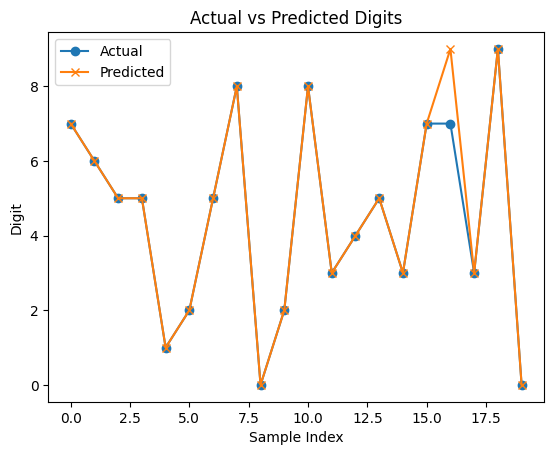

In [12]:
import matplotlib.pyplot as plt

n = 20

plt.figure()
plt.plot(actual[:n], marker='o', label='Actual')
plt.plot(predictions[:n], marker='x', label='Predicted')

plt.title("Actual vs Predicted Digits")
plt.xlabel("Sample Index")
plt.ylabel("Digit")
plt.legend()

plt.show()


In [13]:
conf_matrix = np.zeros((10,10), dtype=int)

for i in range(len(actual)):
    conf_matrix[actual[i]][predictions[i]] += 1

print(conf_matrix)


[[23  0  0  0  0  0  0  0  0  0]
 [ 0 27  0  0  0  0  0  0  0  0]
 [ 0  0 47  0  0  0  0  0  0  0]
 [ 0  0  0 35  0  1  0  0  0  0]
 [ 0  0  0  0 27  0  0  0  0  0]
 [ 0  0  0  0  0 44  0  1  0  0]
 [ 0  1  0  0  0  0 37  0  0  0]
 [ 0  0  0  0  0  0  0 30  0  5]
 [ 1  1  0  0  0  1  0  0 36  0]
 [ 0  0  0  0  0  1  0  0  0 42]]


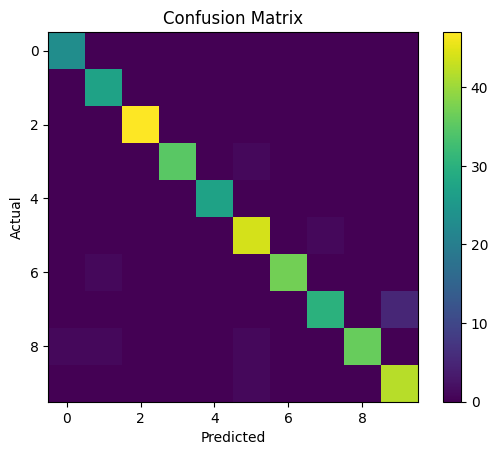

In [14]:
plt.figure()
plt.imshow(conf_matrix)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.colorbar()

plt.show()
